<h2>Exercise 08: Seaborn</h2>

In [4]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# !pip install seaborn

In [ ]:
import sys
!{sys.executable} -m pip install --upgrade --force-reinstall seaborn

  Using cached numpy-2.4.2-cp311-cp311-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.8-cp311-cp311-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp311-cp311-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp311-cp311-macosx_10_9_universal2.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp311-cp311-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached pillow-12.1.1-cp311-cp311-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp311-cp311-macosx_11_0_arm64.whl (8.1 MB)
Using cached numpy-2.4.2-cp311-cp311-macosx_14_0_arm64.whl (5.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 2.3 MB/s eta 0:00:00a 0:00:01
Using cached contourpy-1.3.3-cp311-cp311-macosx_11_0_arm64.whl (270 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fontt

### Preprocessing

In [ ]:
conn = sqlite3.connect("../data/checking-logs.sqlite")

In [8]:
df_checker  = pd.io.sql.read_sql(
    """
    SELECT
        *
    FROM checker
    WHERE 
        labname LIKE "project1" 
        AND uid LIKE "user_%"
        AND status = "ready"
    """,
    conn,
    parse_dates=["timestamp"]
)

df_checker

,index,status,success,timestamp,numTrials,labname,uid
0,7,ready,0,2020-04-17 05:19:02.744528,1,project1,user_4
1,9,ready,1,2020-04-17 05:22:45.549397,2,project1,user_4
2,11,ready,1,2020-04-17 05:34:24.422370,3,project1,user_4
3,13,ready,0,2020-04-17 05:43:27.773992,4,project1,user_4
4,15,ready,1,2020-04-17 05:46:32.275104,5,project1,user_4
...,...,...,...,...,...,...,...
946,3186,ready,1,2020-05-15 10:22:39.698523,26,project1,user_19
947,3187,ready,0,2020-05-15 10:22:46.248162,27,project1,user_19
948,3189,ready,1,2020-05-15 10:23:18.043212,28,project1,user_19
949,3191,ready,1,2020-05-15 10:38:14.430013,27,project1,user_28


In [9]:
df_checker["date"] = df_checker["timestamp"].dt.date
commits_per_day = pd.crosstab(df_checker['date'], df_checker['uid'])
commits_per_day

uid,user_1,user_10,user_11,user_12,user_13,user_14,user_15,user_16,user_17,user_18,...,user_26,user_27,user_28,user_29,user_3,user_30,user_31,user_4,user_6,user_8
date,,,,,,,,,,,,,,,,,,,,,
2020-04-17,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,7,0,0
2020-04-18,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2020-04-19,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,4,0,0
2020-04-22,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2020-04-23,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,9,0,0
2020-04-24,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,7,0,0
2020-05-03,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,8,0,0
2020-05-04,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,13,0,0
2020-05-05,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,5,0,0


In [10]:
cumulative_matrix = commits_per_day.cumsum()
cumulative_matrix

uid,user_1,user_10,user_11,user_12,user_13,user_14,user_15,user_16,user_17,user_18,...,user_26,user_27,user_28,user_29,user_3,user_30,user_31,user_4,user_6,user_8
date,,,,,,,,,,,,,,,,,,,,,
2020-04-17,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,7,0,0
2020-04-18,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,7,0,0
2020-04-19,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,11,0,0
2020-04-22,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,11,0,0
2020-04-23,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,2,0,20,0,0
2020-04-24,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,2,0,27,0,0
2020-05-03,0,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,4,0,35,0,0
2020-05-04,0,0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,5,0,48,0,0
2020-05-05,0,0,1,0,0,1,0,0,1,0,...,0,0,0,0,0,5,0,53,0,0


 ### Result

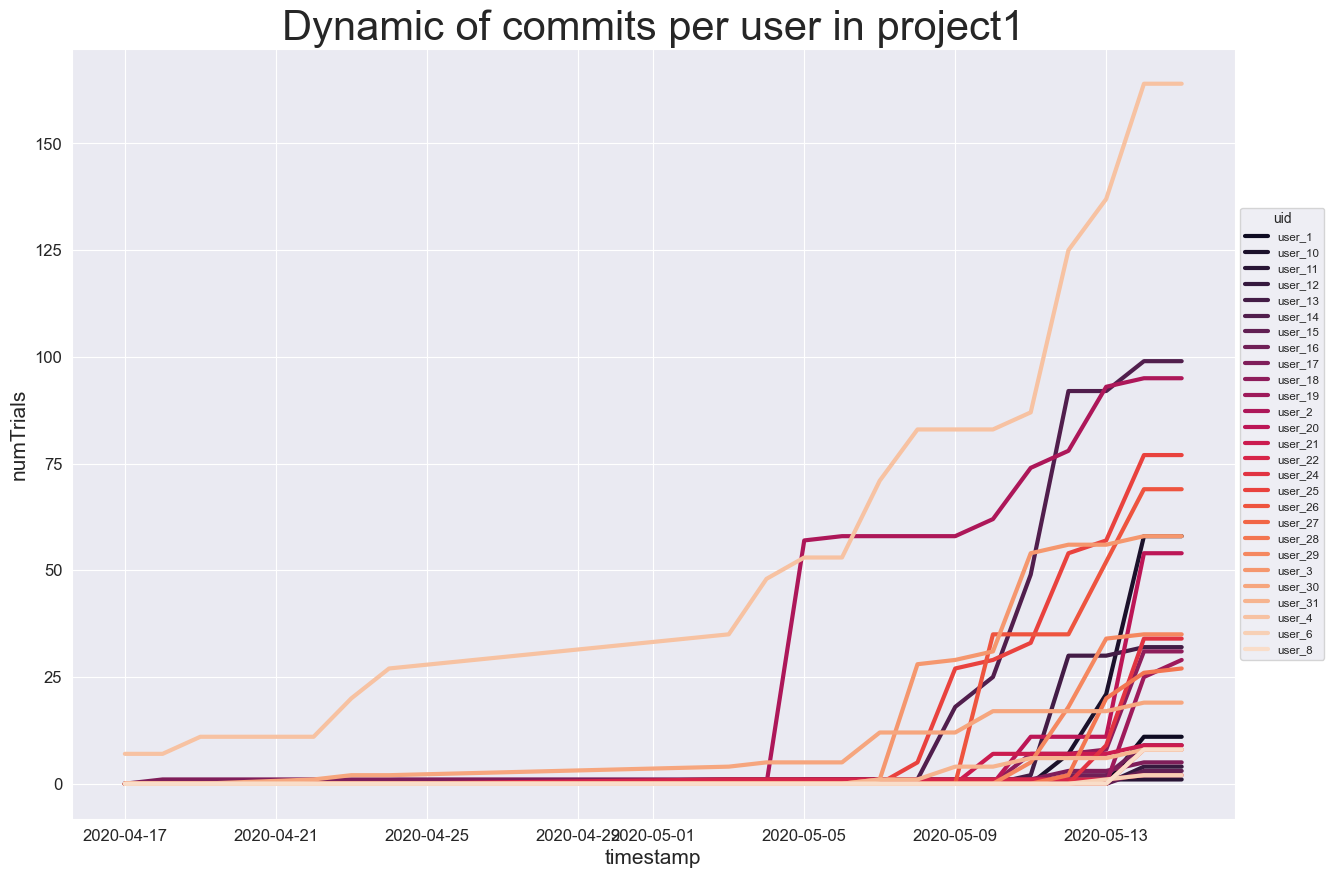

In [ ]:
# Настройка стиля (серый фон)
sns.set_style("darkgrid")

# Размер: Высота 10, Ширина 15
plt.figure(figsize=(15, 10))

# Строим график
# ВАЖНО: Мы передаем всю матрицу в data. 
# dash=False отключает пунктирные линии (делает все сплошными)
sns.lineplot(
    data=cumulative_matrix, 
    linewidth=3, 
    palette='rocket', 
    dashes=False 
)
plt.legend(
    title='uid',               # Заголовок легенды
    loc='center left',         # Какой точкой "стыковать" легенду (левый центр легенды...)
    bbox_to_anchor=(1, 0.5),   # ...стыкуется с координатой (X=1, Y=0.5) графика
    fontsize='small'           # Размер шрифта (можно 'x-small', 'medium' или число)
)
# Настройки шрифтов
plt.title('Dynamic of commits per user in project1', fontsize=30)
plt.xlabel('timestamp', fontsize=15)
plt.ylabel('numTrials', fontsize=15)
plt.tick_params(labelsize=12)

plt.show()

<h2>Answer:</h2>
<h2>User_4</h2>
<h2>User_2</h2>

In [12]:
conn.close()